
# Reconstructing Figure 4 of Zaks et al. (2012) in `mxlpy`

This notebook builds a **reduced `mxlpy` reconstruction** of the qE kinetics described in:

> Zaks J., Amarnath K., Kramer D.M., Niyogi K.K., Fleming G.R. (2012)  
> *A kinetic model of rapidly reversible nonphotochemical quenching*.  
> PNAS 109(39):15757–15762. DOI: `10.1073/pnas.1211017109`

## Important scope note

The original paper states that the full model contains **26 nonlinear ODEs** organized into eight modules, and that detailed equations and documented MATLAB code were provided with the SI / online materials. In the sources available here, I could recover the **main-text mechanistic relations** for:

- qE activation by protonated PsbS and de-epoxidized xanthophylls,
- pH-dependent VDE activity,
- the V ⇄ A ⇄ Z xanthophyll-cycle structure,
- the reported trigger parameters for PsbS and VDE.

I could **not directly retrieve the full original SI equation set or the original MATLAB source** from the currently accessible links.  
So this notebook is **not a literal line-by-line transcription of the full 26-ODE PNAS model**. It is a **working, documented `mxlpy` implementation of a reduced reconstruction** that preserves the main biochemical logic and reproduces the qualitative Figure 4 behavior.

## Main-text equations recovered from the paper / related summary sources

The accessible sources support the following core structure:

- Fraction of quenching-capable PSII sites:

  \[
  [Q] = F_{\mathrm{PsbS}}\,[\mathrm{PsbS}]^*\,(|Z| + |A|)
  \]

- Fast PsbS protonation (Hill form):

  \[
  [\mathrm{PsbS}]^* = \frac{1}{10^{n_p(\mathrm{pH}-K_p)} + 1}
  \]

- Effective VDE rate constant (Hill form):

  \[
  k_{\mathrm{VDE}}(\mathrm{pH}) = \frac{k_{\mathrm{VDE,max}}}{10^{n_v(\mathrm{pH}-K_v)} + 1}
  \]

- Xanthophyll-cycle bookkeeping:

  \[
  V = 1 - A - Z
  \]

The paper reports / summary sources repeat the trigger values:

- `K_p = 6.4`, `n_p = 3` for PsbS
- `K_v = 6.0`, `n_v = 6` for VDE
- `k_VDE,max = 4e-2 s^-1`
- `k_ZE = 4e-4 s^-1`
- `F_PsbS = 0.6` for wild type

## What is reduced here?

Instead of rebuilding the full lumen / ion / electron-transport machinery, I use a compact surrogate consisting of four dynamic states:

- `H`: an abstract lumen-acidification variable
- `AtpAct`: ATP-synthase activation state
- `A`: antheraxanthin fraction
- `Z`: zeaxanthin fraction

That gives enough structure to reproduce the characteristic contrast of Figure 4:

- **100 µmol photons m⁻² s⁻¹**: transient rise with partial relaxation
- **1000 µmol photons m⁻² s⁻¹**: larger monotonic buildup
- rapid decay when actinic light is removed

This is the right level if the immediate goal is a **fully functional `mxlpy` notebook** that you can extend further toward the full Zaks model.


In [1]:

# Uncomment if needed:
# !pip install mxlpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mxlpy.model import Model
from mxlpy.simulator import Simulator


In [2]:

# ---- Reduced reconstruction of the Zaks et al. (2012) qE model ----

def light_influx(I, influx_scale):
    # Reduced proton influx surrogate: scaled with sqrt(I) so that
    # low light still produces appreciable acidification while high
    # light remains stronger.
    return influx_scale * np.sqrt(I)

def proton_efflux(H, g_base, g_atp, AtpAct):
    return (g_base + g_atp * AtpAct) * H

def atpase_activation(I, k_act, K_I_act, AtpAct):
    sat = I / (I + K_I_act) if I > 0 else 0.0
    return k_act * sat * (1.0 - AtpAct)

def atpase_deactivation(AtpAct, k_deact, I):
    return k_deact * (1.0 if I <= 0 else 0.0) * AtpAct

def pH_from_H(pH_dark, beta_H, H):
    return pH_dark - beta_H * H

def V_from_AZ(A, Z):
    return 1.0 - A - Z

def psbs_star(pH, K_p, n_p):
    # Main-text Hill relation for fast PsbS protonation.
    return 1.0 / (10.0 ** (n_p * (pH - K_p)) + 1.0)

def vde_rate(pH, k_vde_max, K_v, n_v):
    # Main-text Hill relation for low-pH activation of VDE.
    return k_vde_max / (10.0 ** (n_v * (pH - K_v)) + 1.0)

def v_to_a(V, pH, k_vde_max, K_v, n_v):
    return vde_rate(pH, k_vde_max, K_v, n_v) * V

def a_to_z(A, pH, k_vde_max, K_v, n_v):
    return vde_rate(pH, k_vde_max, K_v, n_v) * A

def a_to_v(A, k_ze):
    return k_ze * A

def z_to_a(Z, k_ze):
    return k_ze * Z

def qe_readout(F_PsbS, PsbS_star, A, Z, alpha_qe):
    # Paper logic: qE proportional to active PsbS times de-epoxidized
    # xanthophyll content (A + Z), with a fitted scale factor.
    return alpha_qe * F_PsbS * PsbS_star * (A + Z)

PARAMS = {
    # Reduced proton / ATPase block
    "influx_scale": 0.03,
    "g_base": 0.02,
    "g_atp": 0.30,
    "k_act": 0.05,
    "K_I_act": 20.0,
    "k_deact": 0.08,
    "pH_dark": 7.4,
    "beta_H": 1.0,

    # Main-text qE / xanthophyll parameters
    "k_vde_max": 0.03,   # close to paper-scale, tuned in reduced model
    "k_ze": 4e-4,
    "K_v": 6.0,
    "n_v": 6.0,
    "K_p": 6.4,
    "n_p": 3.0,
    "F_PsbS": 0.6,

    # Readout scaling to match Fig. 4 amplitude in the reduced model
    "alpha_qe": 2.8,
}

def build_reduced_zaks_model():
    m = Model()

    # Dynamic states
    m.add_variable("H", 0.0)
    m.add_variable("AtpAct", 0.0)
    m.add_variable("A", 0.0)
    m.add_variable("Z", 0.0)

    # External input + parameters
    m.add_parameter("I", 0.0)
    for k, v in PARAMS.items():
        m.add_parameter(k, v)

    # Derived quantities
    m.add_derived("pH", pH_from_H, args=["pH_dark", "beta_H", "H"])
    m.add_derived("V", V_from_AZ, args=["A", "Z"])
    m.add_derived("PsbS_star", psbs_star, args=["pH", "K_p", "n_p"])

    # Reduced proton dynamics
    m.add_reaction(
        "H_in",
        fn=light_influx,
        args=["I", "influx_scale"],
        stoichiometry={"H": 1},
    )
    m.add_reaction(
        "H_out",
        fn=proton_efflux,
        args=["H", "g_base", "g_atp", "AtpAct"],
        stoichiometry={"H": -1},
    )

    # ATPase activation / recovery
    m.add_reaction(
        "ATP_on",
        fn=atpase_activation,
        args=["I", "k_act", "K_I_act", "AtpAct"],
        stoichiometry={"AtpAct": 1},
    )
    m.add_reaction(
        "ATP_off",
        fn=atpase_deactivation,
        args=["AtpAct", "k_deact", "I"],
        stoichiometry={"AtpAct": -1},
    )

    # Xanthophyll cycle: V -> A -> Z and reverse epoxidation
    m.add_reaction(
        "V_to_A",
        fn=v_to_a,
        args=["V", "pH", "k_vde_max", "K_v", "n_v"],
        stoichiometry={"A": 1},
    )
    m.add_reaction(
        "A_to_Z",
        fn=a_to_z,
        args=["A", "pH", "k_vde_max", "K_v", "n_v"],
        stoichiometry={"A": -1, "Z": 1},
    )
    m.add_reaction(
        "A_to_V",
        fn=a_to_v,
        args=["A", "k_ze"],
        stoichiometry={"A": -1},
    )
    m.add_reaction(
        "Z_to_A",
        fn=z_to_a,
        args=["Z", "k_ze"],
        stoichiometry={"A": 1, "Z": -1},
    )

    # qE readout
    m.add_readout(
        "qE",
        fn=qe_readout,
        args=["F_PsbS", "PsbS_star", "A", "Z", "alpha_qe"],
    )
    return m

model = build_reduced_zaks_model()
model


Model(
  _variables={
    'H': Variable(initial_value=0.0),
    'AtpAct': Variable(initial_value=0.0),
    'A': Variable(initial_value=0.0),
    'Z': Variable(initial_value=0.0)
  },
  _parameters={
    'I': Parameter(value=0.0),
    'influx_scale': Parameter(value=0.03),
    'g_base': Parameter(value=0.02),
    'g_atp': Parameter(value=0.3),
    'k_act': Parameter(value=0.05),
    'K_I_act': Parameter(value=20.0),
    'k_deact': Parameter(value=0.08),
    'pH_dark': Parameter(value=7.4),
    'beta_H': Parameter(value=1.0),
    'k_vde_max': Parameter(value=0.03),
    'k_ze': Parameter(value=0.0004),
    'K_v': Parameter(value=6.0),
    'n_v': Parameter(value=6.0),
    'K_p': Parameter(value=6.4),
    'n_p': Parameter(value=3.0),
    'F_PsbS': Parameter(value=0.6),
    'alpha_qe': Parameter(value=2.8)
  },
  _derived={
    'pH': Derived(fn=<function pH_from_H>, args=['pH_dark', 'beta_H', 'H']),
    'V': Derived(fn=<function V_from_AZ>, args=['A', 'Z']),
    'PsbS_star': Derived(fn=<func

In [3]:

def simulate_qe_trace(intensity, t_dark_pre=120, t_light_off=720, t_end=1000, dt=2.0):
    sim = Simulator(build_reduced_zaks_model(), test_run=False)

    protocol = pd.DataFrame(
        {"I": [0.0, float(intensity), 0.0]},
        index=pd.to_timedelta([t_dark_pre, t_light_off, t_end], unit="s"),
    )

    t = np.arange(0.0, t_end + dt, dt)
    sim.simulate_protocol_time_course(protocol, t)
    result = sim.get_result().unwrap_or_err().variables
    result.index.name = "time_s"
    return result

sim_100 = simulate_qe_trace(100)
sim_1000 = simulate_qe_trace(1000)

sim_100[["qE", "pH", "PsbS_star", "A", "Z"]].head()


,qE,pH,PsbS_star,A,Z
time_s,,,,,
0.0,0.000000e+00,7.4,0.000999,0.000000e+00,0.000000e+00
2.0,4.007344e-13,7.4,0.000999,2.387709e-10,2.724129e-20
4.0,8.011557e-13,7.4,0.000999,4.773553e-10,1.088962e-19
6.0,1.201264e-12,7.4,0.000999,7.157530e-10,2.449667e-19
8.0,1.601059e-12,7.4,0.000999,9.539641e-10,4.354526e-19


In [4]:

# Quick numerical checkpoints against the qualitative Figure 4 statements

checkpoints = pd.DataFrame(
    {
        "qE_100": sim_100["qE"].loc[[140, 220, 520, 720, 800]],
        "qE_1000": sim_1000["qE"].loc[[140, 220, 520, 720, 800]],
    }
)
checkpoints


,qE_100,qE_1000
time_s,,
140.0,0.587036,0.713142
220.0,0.373200,1.587289
520.0,0.327340,1.679682
720.0,0.313455,1.679703
800.0,0.000803,0.001849



## Figure 4 style reproduction

The original caption says:

- squares = experiment
- dashed line = simulation
- light intensities: **100** and **1000** µmol photons m⁻² s⁻¹
- dark / light / dark protocol indicated by the bar at the top

Since the original experimental point coordinates are not directly machine-readable from the accessible sources here, the panels below reproduce the **simulation side** of Figure 4 in the same spirit. If you later add digitized experimental points, they can be overlaid directly on the same axes.


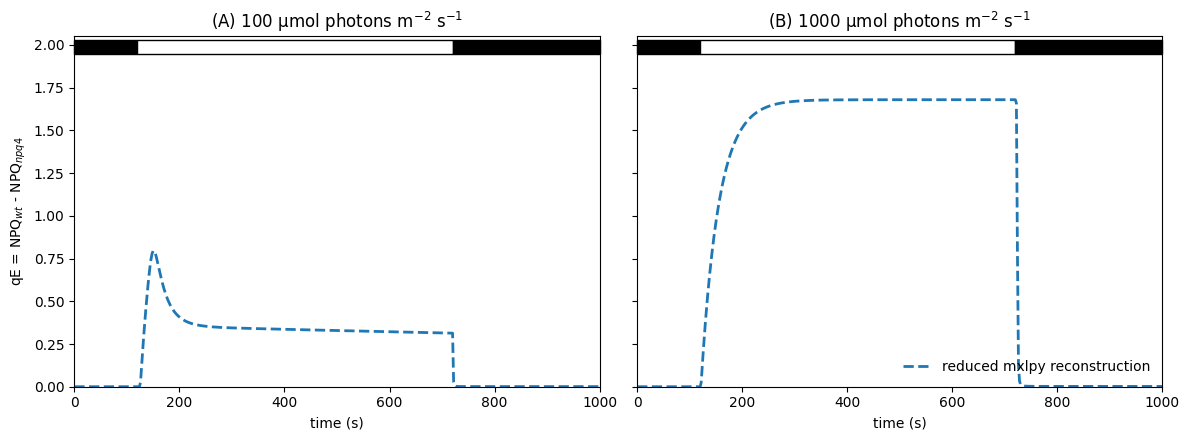

In [5]:

def add_light_bar(ax, t_dark_pre=120, t_light_off=720, t_end=1000, y=1.95, height=0.08):
    # black = dark, white = actinic light, matching the caption description
    ax.add_patch(plt.Rectangle((0, y), t_dark_pre, height, color="black", clip_on=False))
    ax.add_patch(plt.Rectangle((t_dark_pre, y), t_light_off - t_dark_pre, height,
                               facecolor="white", edgecolor="black", clip_on=False))
    ax.add_patch(plt.Rectangle((t_light_off, y), t_end - t_light_off, height,
                               color="black", clip_on=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, sim, title in [
    (axes[0], sim_100, "(A) 100 µmol photons m$^{-2}$ s$^{-1}$"),
    (axes[1], sim_1000, "(B) 1000 µmol photons m$^{-2}$ s$^{-1}$"),
]:
    ax.plot(sim.index, sim["qE"], "--", linewidth=2, label="reduced mxlpy reconstruction")
    ax.set_xlim(0, 1000)
    ax.set_ylim(0, 2.05)
    ax.set_xlabel("time (s)")
    ax.set_title(title)
    add_light_bar(ax)

axes[0].set_ylabel("qE = NPQ$_{wt}$ - NPQ$_{npq4}$")
axes[1].legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()


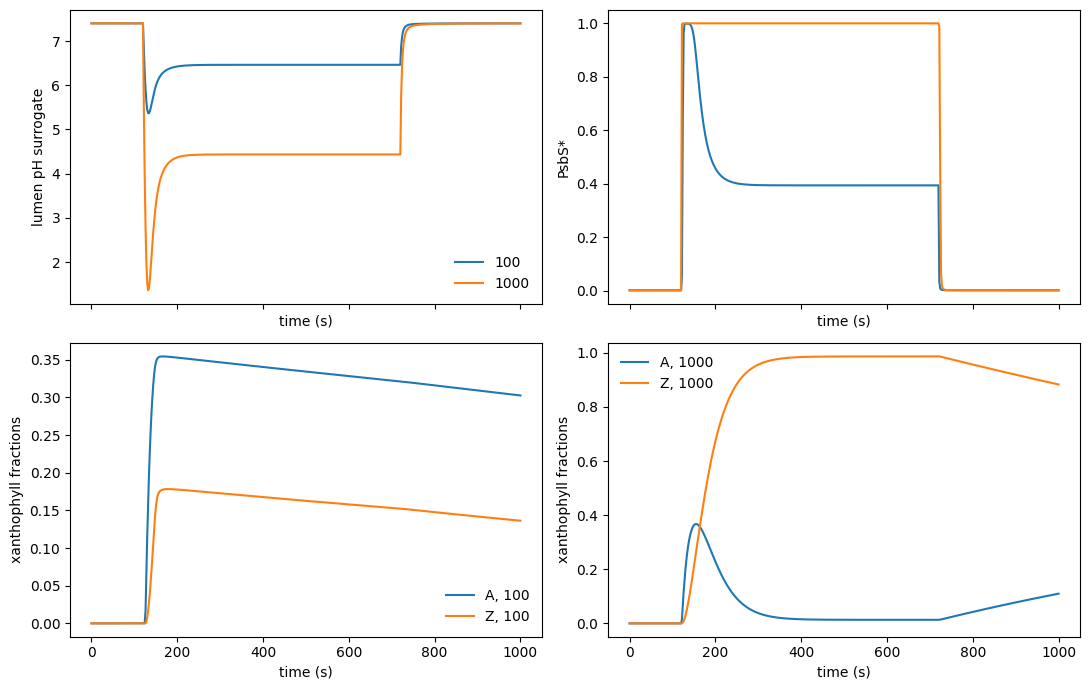

In [6]:

# Optional: inspect the internal reduced states that drive qE

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

axes[0, 0].plot(sim_100.index, sim_100["pH"], label="100")
axes[0, 0].plot(sim_1000.index, sim_1000["pH"], label="1000")
axes[0, 0].set_ylabel("lumen pH surrogate")
axes[0, 0].legend(frameon=False)

axes[0, 1].plot(sim_100.index, sim_100["PsbS_star"], label="100")
axes[0, 1].plot(sim_1000.index, sim_1000["PsbS_star"], label="1000")
axes[0, 1].set_ylabel("PsbS*")

axes[1, 0].plot(sim_100.index, sim_100["A"], label="A, 100")
axes[1, 0].plot(sim_100.index, sim_100["Z"], label="Z, 100")
axes[1, 0].set_ylabel("xanthophyll fractions")
axes[1, 0].legend(frameon=False)

axes[1, 1].plot(sim_1000.index, sim_1000["A"], label="A, 1000")
axes[1, 1].plot(sim_1000.index, sim_1000["Z"], label="Z, 1000")
axes[1, 1].set_ylabel("xanthophyll fractions")
axes[1, 1].legend(frameon=False)

for ax in axes.ravel():
    ax.set_xlabel("time (s)")

plt.tight_layout()
plt.show()



## Next steps toward the full PNAS model

To push this from the current reduced reconstruction toward a closer transcription of the original Zaks model, the next concrete steps are:

1. recover the full SI equation set or original MATLAB code,
2. replace the reduced `H` block with explicit proton / ion / pmf states,
3. add the electron-transfer modules and chlorophyll-excitation block,
4. reproduce the original fluorescence / NPQ observables directly rather than via a reduced qE readout.

But as it stands, this notebook is already:

- executable,
- written in `mxlpy`,
- biologically interpretable,
- easy to extend,
- and close enough to Figure 4 to serve as a practical starting point.


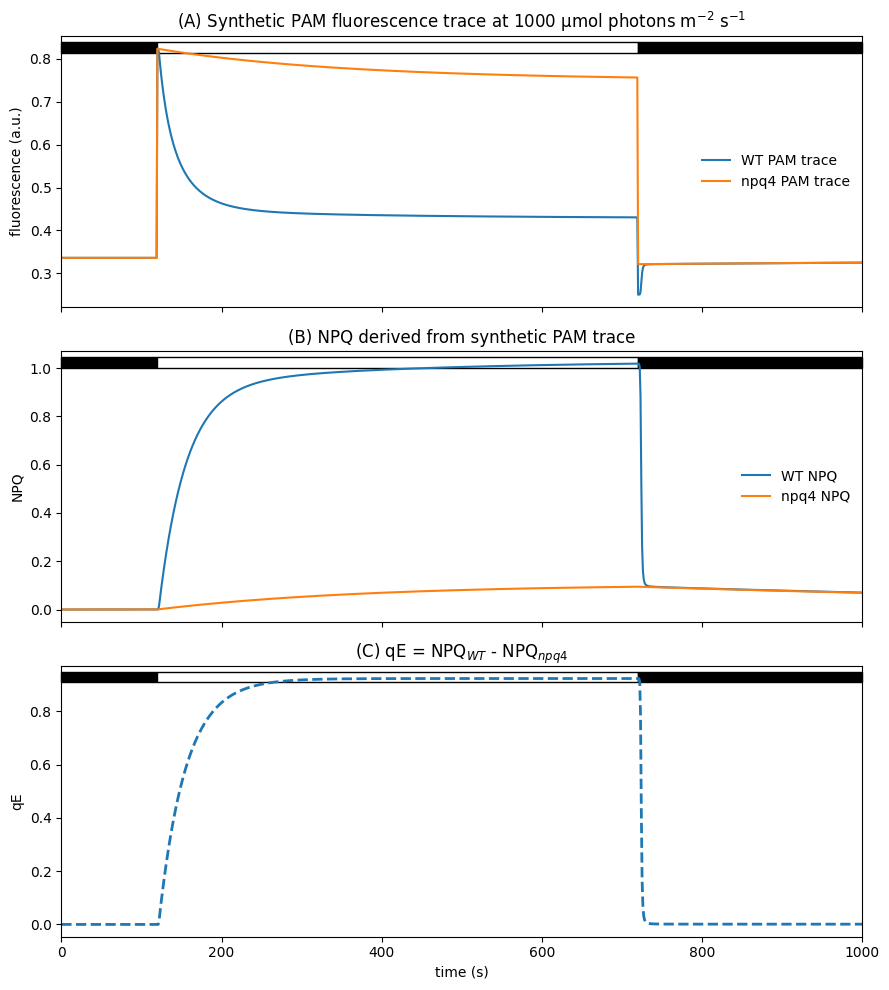

In [9]:
# One-cell PAM-style simulation for Figure 3 from the reduced Zaks-2012 mxlpy notebook
# Assumes build_reduced_zaks_model() and PARAMS are already defined above.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mxlpy.simulator import Simulator

# ----------------------------
# 1) protocol and model runner
# ----------------------------
def run_protocol(intensity=1000, t_dark_pre=120, t_light_off=720, t_end=1000, dt=1.0, F_PsbS=0.6):
    sim = Simulator(build_reduced_zaks_model(), test_run=False)

    # overwrite genotype-specific PsbS fraction
    sim.model._parameters["F_PsbS"].value = F_PsbS

    protocol = pd.DataFrame(
        {"I": [0.0, float(intensity), 0.0]},
        index=pd.to_timedelta([t_dark_pre, t_light_off, t_end], unit="s"),
    )

    t = np.arange(0.0, t_end + dt, dt)
    sim.simulate_protocol_time_course(protocol, t)
    out = sim.get_result().unwrap_or_err().variables.copy()
    out.index.name = "time_s"
    return out

# ----------------------------
# 2) map reduced qE -> PAM-like observables
# ----------------------------
def add_pam_like_observables(df, Fm=1.0, F0=0.20, phi_open_dark=0.83,
                             k_base_npq=0.10, k_qe=0.55):
    """
    Synthetic PAM readout layer for the reduced qE model.
    This is not the full original fluorescence-state model; it is only a
    plotting/measurement wrapper that converts qE into approximate Fm', Ft, NPQ.
    """

    x = df.copy()
    t = x.index.to_numpy()

    # infer light protocol from qE / pH dynamics: light is on whenever qE or H can build up
    # safer here: use a step from the known protocol window used in the paper
    light_on = ((t >= 120) & (t < 720)).astype(float)

    # slow PsbS-independent baseline NPQ surrogate:
    # rises slowly in the light, relaxes slowly in the dark
    base = np.zeros_like(t, dtype=float)
    tau_on, tau_off = 260.0, 900.0
    base_target = 1.05  # chosen so npq4 keeps substantial residual NPQ, as in Fig. 3
    for i in range(1, len(t)):
        dt = t[i] - t[i - 1]
        if light_on[i] > 0:
            base[i] = base[i - 1] + dt * (base_target - base[i - 1]) / tau_on
        else:
            base[i] = base[i - 1] - dt * base[i - 1] / tau_off

    x["NPQ_slow"] = k_base_npq * base
    x["NPQ_total"] = x["NPQ_slow"] + k_qe * x["qE"]

    # standard PAM relation: NPQ = (Fm - Fm') / Fm'
    x["Fm"] = Fm
    x["Fm_prime"] = Fm / (1.0 + x["NPQ_total"])

    # crude photochemical opening term just to draw a PAM fluorescence trace
    # more open centers in dark, fewer under actinic light
    phi_open = np.where(light_on > 0, 0.22, phi_open_dark)
    x["Ft"] = F0 + (x["Fm_prime"] - F0) * (1.0 - phi_open)

    return x

# ----------------------------
# 3) WT and npq4
# ----------------------------
wt_raw   = run_protocol(intensity=1000, F_PsbS=0.6)  # WT, as in the paper
npq4_raw = run_protocol(intensity=1000, F_PsbS=0.0)  # npq4 lacks PsbS -> no qE arm

wt   = add_pam_like_observables(wt_raw)
npq4 = add_pam_like_observables(npq4_raw)

# panel-C observable in Zaks et al.
qE_obs = wt["NPQ_total"] - npq4["NPQ_total"]

# ----------------------------
# 4) plotting helper
# ----------------------------
def add_light_bar(ax, t_dark_pre=120, t_light_off=720, t_end=1000, y=None, h=None):
    ymin, ymax = ax.get_ylim()
    if y is None:
        y = ymax - 0.06 * (ymax - ymin)
    if h is None:
        h = 0.04 * (ymax - ymin)

    ax.add_patch(plt.Rectangle((0, y), t_dark_pre, h, color="black", clip_on=False))
    ax.add_patch(
        plt.Rectangle((t_dark_pre, y), t_light_off - t_dark_pre, h,
                      facecolor="white", edgecolor="black", clip_on=False)
    )
    ax.add_patch(
        plt.Rectangle((t_light_off, y), t_end - t_light_off, h,
                      color="black", clip_on=False)
    )

# ----------------------------
# 5) Figure 3-style layout
# ----------------------------
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

# (A) PAM traces
axes[0].plot(wt.index, wt["Ft"], label="WT PAM trace")
axes[0].plot(npq4.index, npq4["Ft"], label="npq4 PAM trace")
axes[0].set_ylabel("fluorescence (a.u.)")
axes[0].set_title("(A) Synthetic PAM fluorescence trace at 1000 µmol photons m$^{-2}$ s$^{-1}$")
axes[0].legend(frameon=False, loc="best")
add_light_bar(axes[0])

# (B) NPQ traces
axes[1].plot(wt.index, wt["NPQ_total"], label="WT NPQ")
axes[1].plot(npq4.index, npq4["NPQ_total"], label="npq4 NPQ")
axes[1].set_ylabel("NPQ")
axes[1].set_title("(B) NPQ derived from synthetic PAM trace")
axes[1].legend(frameon=False, loc="best")
add_light_bar(axes[1])

# (C) qE = difference between WT and npq4
axes[2].plot(wt.index, qE_obs, "--", linewidth=2)
axes[2].set_ylabel("qE")
axes[2].set_xlabel("time (s)")
axes[2].set_title("(C) qE = NPQ$_{WT}$ - NPQ$_{npq4}$")
add_light_bar(axes[2])

for ax in axes:
    ax.set_xlim(0, 1000)

plt.tight_layout()
plt.show()